In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
import os
from datetime import datetime, timedelta
import json


In [2]:
warnings.filterwarnings('ignore')

🏙️  CITY ENERGY CONSUMPTION ANALYSIS & PREDICTION SYSTEM

📊 Step 1: Generating synthetic dataset...
Generating synthetic dataset...
Generated dataset with 1825 records for 5 zones over 365 days

🧹 Step 2: Cleaning and preprocessing data...
Cleaning and preprocessing data...
Data cleaning completed

🔍 Step 3: Analyzing consumption patterns...

Analyzing energy consumption patterns...

Monthly Statistics (Average Energy Consumption):
ZoneID       1        2        3       4       5
Month                                           
1       532.01   901.58  1285.14  496.16  742.53
2       561.88   987.72  1441.80  529.15  784.84
3       577.94  1000.87  1448.47  545.07  794.49
4       588.96   973.91  1450.12  543.83  803.38
5       565.61   957.40  1416.30  536.02  788.64
6       532.21   927.33  1319.89  496.61  732.66
7       462.26   782.33  1170.76  446.51  659.30
8       413.49   713.75  1061.12  381.47  587.74
9       375.75   654.64   988.09  361.97  537.96
10      382.87   662.42  

Traceback (most recent call last):
  File "C:\Users\91839\AppData\Local\Temp\ipykernel_17332\2149937711.py", line 677, in main
    analyzer.save_model_and_data()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\91839\AppData\Local\Temp\ipykernel_17332\2149937711.py", line 558, in save_model_and_data
    self.data.to_csv('energy_data.csv', index=False)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\91839\anaconda3\Lib\site-packages\pandas\util\_decorators.py", line 333, in wrapper
    return func(*args, **kwargs)
  File "C:\Users\91839\anaconda3\Lib\site-packages\pandas\core\generic.py", line 3967, in to_csv
    return DataFrameRenderer(formatter).to_csv(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        path_or_buf,
        ^^^^^^^^^^^^
    ...<14 lines>...
        storage_options=storage_options,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\91839\anaconda3\Lib\site-packages\pandas\io\formats\format.py", line 1014, in to_csv
    

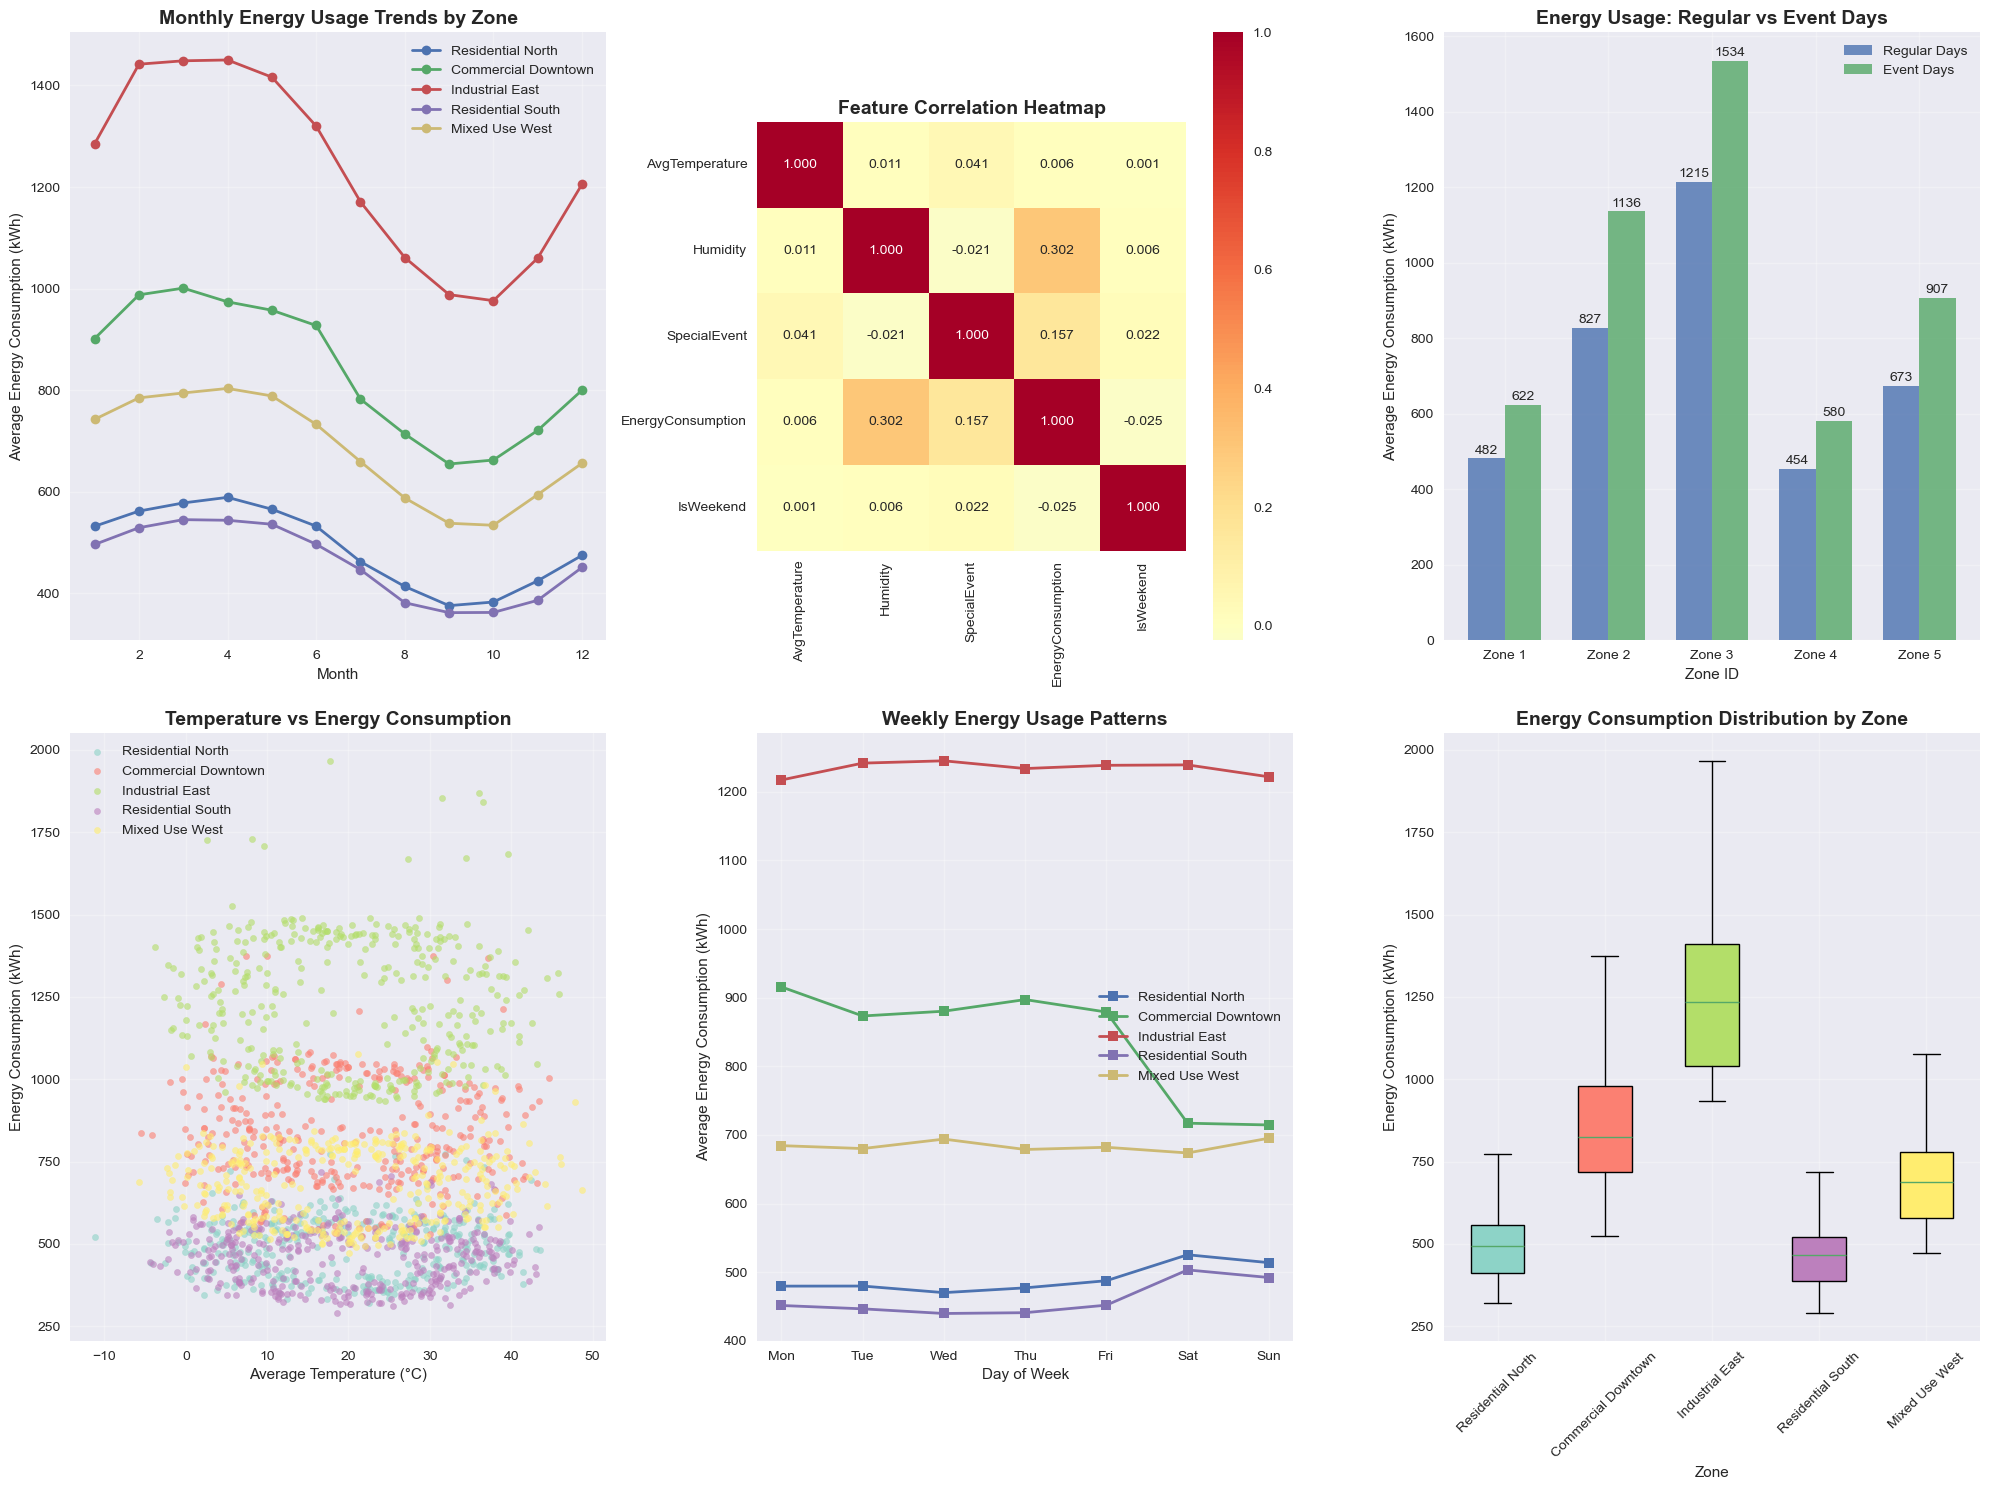

In [8]:

class CityEnergyAnalyzer:
    def __init__(self):
        self.data = None
        self.model = None
        self.scaler = StandardScaler()
        self.zone_info = {}
        
    def generate_synthetic_data(self, num_zones=5, days=365):
        """Generate synthetic energy consumption data for city zones"""
        print("Generating synthetic dataset...")
        
        # Create date range
        start_date = datetime(2023, 1, 1)
        dates = [start_date + timedelta(days=x) for x in range(days)]
        
        # Zone characteristics (different consumption patterns)
        zone_types = {
            1: {'name': 'Residential North', 'base_consumption': 450, 'temp_sensitivity': 15},
            2: {'name': 'Commercial Downtown', 'base_consumption': 850, 'temp_sensitivity': 25},
            3: {'name': 'Industrial East', 'base_consumption': 1200, 'temp_sensitivity': 10},
            4: {'name': 'Residential South', 'base_consumption': 420, 'temp_sensitivity': 18},
            5: {'name': 'Mixed Use West', 'base_consumption': 650, 'temp_sensitivity': 20}
        }
        
        self.zone_info = zone_types
        
        data = []
        
        for zone_id in range(1, num_zones + 1):
            zone_data = zone_types[zone_id]
            base_consumption = zone_data['base_consumption']
            temp_sensitivity = zone_data['temp_sensitivity']
            
            for i, date in enumerate(dates):
                # Seasonal temperature variation
                day_of_year = date.timetuple().tm_yday
                base_temp = 20 + 15 * np.sin(2 * np.pi * day_of_year / 365 - np.pi/2)
                temperature = base_temp + np.random.normal(0, 5)
                
                # Humidity varies with season and some randomness
                humidity = 50 + 20 * np.sin(2 * np.pi * day_of_year / 365) + np.random.normal(0, 10)
                humidity = max(20, min(90, humidity))  # Keep humidity realistic
                
                # Special events (festivals, sports events, etc.) - about 5% of days
                special_event = 1 if np.random.random() < 0.05 else 0
                
                # Energy consumption calculation
                # Base consumption varies by zone
                consumption = base_consumption
                
                # Temperature effect (higher consumption on very hot or cold days)
                temp_effect = temp_sensitivity * (abs(temperature - 22) / 10)
                consumption += temp_effect
                
                # Humidity effect (small impact)
                humidity_effect = (humidity - 50) * 0.5
                consumption += humidity_effect
                
                # Weekend effect (residential zones use more, commercial less)
                if date.weekday() >= 5:  # Weekend
                    if zone_id in [1, 4]:  # Residential zones
                        consumption *= 1.1
                    elif zone_id == 2:  # Commercial
                        consumption *= 0.8
                
                # Special event effect
                if special_event:
                    consumption *= np.random.uniform(1.2, 1.5)
                
                # Add some random noise
                consumption += np.random.normal(0, 20)
                consumption = max(100, consumption)  # Ensure positive consumption
                
                # Seasonal variation
                season_multiplier = 1 + 0.2 * np.sin(2 * np.pi * day_of_year / 365)
                consumption *= season_multiplier
                
                data.append({
                    'Date': date.strftime('%Y-%m-%d'),
                    'ZoneID': zone_id,
                    'AvgTemperature': round(temperature, 1),
                    'Humidity': round(humidity, 1),
                    'SpecialEvent': special_event,
                    'EnergyConsumption': round(consumption, 2)
                })
        
        self.data = pd.DataFrame(data)
        self.data['Date'] = pd.to_datetime(self.data['Date'])
        self.data['Month'] = self.data['Date'].dt.month
        self.data['DayOfWeek'] = self.data['Date'].dt.dayofweek
        self.data['IsWeekend'] = (self.data['DayOfWeek'] >= 5).astype(int)
        
        print(f"Generated dataset with {len(self.data)} records for {num_zones} zones over {days} days")
        return self.data
    
    def clean_and_preprocess(self):
        """Clean and preprocess the data"""
        print("Cleaning and preprocessing data...")
        
        # Check for missing values
        missing_values = self.data.isnull().sum()
        if missing_values.sum() > 0:
            print("Missing values found:")
            print(missing_values[missing_values > 0])
            # Forward fill missing values
            self.data = self.data.fillna(method='ffill')
        
        # Remove outliers using IQR method
        for zone in self.data['ZoneID'].unique():
            zone_data = self.data[self.data['ZoneID'] == zone]['EnergyConsumption']
            Q1 = zone_data.quantile(0.25)
            Q3 = zone_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Cap outliers instead of removing them
            self.data.loc[
                (self.data['ZoneID'] == zone) & 
                (self.data['EnergyConsumption'] < lower_bound), 
                'EnergyConsumption'
            ] = lower_bound
            
            self.data.loc[
                (self.data['ZoneID'] == zone) & 
                (self.data['EnergyConsumption'] > upper_bound), 
                'EnergyConsumption'
            ] = upper_bound
        
        print("Data cleaning completed")
        
    def analyze_patterns(self):
        """Analyze patterns in energy consumption"""
        print("\nAnalyzing energy consumption patterns...")
        
        # Monthly analysis
        monthly_stats = self.data.groupby(['Month', 'ZoneID'])['EnergyConsumption'].agg([
            'mean', 'std', 'min', 'max'
        ]).round(2)
        
        # Zone analysis
        zone_stats = self.data.groupby('ZoneID')['EnergyConsumption'].agg([
            'mean', 'std', 'min', 'max'
        ]).round(2)
        
        # Correlation analysis
        correlation_matrix = self.data[['AvgTemperature', 'Humidity', 'SpecialEvent', 
                                       'EnergyConsumption', 'IsWeekend']].corr()
        
        # Event vs non-event analysis
        event_analysis = self.data.groupby(['SpecialEvent', 'ZoneID'])['EnergyConsumption'].mean()
        
        print("\nMonthly Statistics (Average Energy Consumption):")
        print(monthly_stats['mean'].unstack())
        
        print("\nZone Statistics:")
        for zone in zone_stats.index:
            zone_name = self.zone_info.get(zone, {}).get('name', f'Zone {zone}')
            print(f"{zone_name}: Avg={zone_stats.loc[zone, 'mean']:.2f} kWh, "
                  f"Std={zone_stats.loc[zone, 'std']:.2f} kWh")
        
        print(f"\nCorrelation with Energy Consumption:")
        energy_corr = correlation_matrix['EnergyConsumption'].sort_values(ascending=False)
        for feature, corr in energy_corr.items():
            if feature != 'EnergyConsumption':
                print(f"{feature}: {corr:.3f}")
        
        return monthly_stats, zone_stats, correlation_matrix, event_analysis
    
    def create_visualizations(self):
        """Create comprehensive visualizations"""
        print("\nCreating visualizations...")
        
        # Set style
        plt.style.use('seaborn-v0_8')
        fig = plt.figure(figsize=(20, 15))
        
        # 1. Monthly Energy Usage Trends (Line Chart)
        plt.subplot(2, 3, 1)
        monthly_data = self.data.groupby(['Month', 'ZoneID'])['EnergyConsumption'].mean().unstack()
        for zone in monthly_data.columns:
            zone_name = self.zone_info.get(zone, {}).get('name', f'Zone {zone}')
            plt.plot(monthly_data.index, monthly_data[zone], marker='o', linewidth=2, 
                    label=zone_name)
        plt.title('Monthly Energy Usage Trends by Zone', fontsize=14, fontweight='bold')
        plt.xlabel('Month')
        plt.ylabel('Average Energy Consumption (kWh)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 2. Correlation Heatmap
        plt.subplot(2, 3, 2)
        correlation_data = self.data[['AvgTemperature', 'Humidity', 'SpecialEvent', 
                                     'EnergyConsumption', 'IsWeekend']].corr()
        sns.heatmap(correlation_data, annot=True, cmap='RdYlBu_r', center=0, 
                   square=True, fmt='.3f')
        plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
        
        # 3. Event vs Non-Event Days Comparison
        plt.subplot(2, 3, 3)
        event_comparison = self.data.groupby(['SpecialEvent', 'ZoneID'])['EnergyConsumption'].mean().unstack()
        x = np.arange(len(event_comparison.columns))
        width = 0.35
        
        bars1 = plt.bar(x - width/2, event_comparison.loc[0], width, label='Regular Days', alpha=0.8)
        bars2 = plt.bar(x + width/2, event_comparison.loc[1], width, label='Event Days', alpha=0.8)
        
        plt.title('Energy Usage: Regular vs Event Days', fontsize=14, fontweight='bold')
        plt.xlabel('Zone ID')
        plt.ylabel('Average Energy Consumption (kWh)')
        plt.xticks(x, [f'Zone {i}' for i in event_comparison.columns])
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                    f'{height:.0f}', ha='center', va='bottom')
        for bar in bars2:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                    f'{height:.0f}', ha='center', va='bottom')
        
        # 4. Temperature vs Energy Consumption Scatter Plot
        plt.subplot(2, 3, 4)
        colors = plt.cm.Set3(np.linspace(0, 1, len(self.data['ZoneID'].unique())))
        for i, zone in enumerate(self.data['ZoneID'].unique()):
            zone_data = self.data[self.data['ZoneID'] == zone]
            zone_name = self.zone_info.get(zone, {}).get('name', f'Zone {zone}')
            plt.scatter(zone_data['AvgTemperature'], zone_data['EnergyConsumption'], 
                       alpha=0.6, c=[colors[i]], label=zone_name, s=20)
        
        plt.title('Temperature vs Energy Consumption', fontsize=14, fontweight='bold')
        plt.xlabel('Average Temperature (°C)')
        plt.ylabel('Energy Consumption (kWh)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 5. Weekly Pattern Analysis
        plt.subplot(2, 3, 5)
        weekly_pattern = self.data.groupby(['DayOfWeek', 'ZoneID'])['EnergyConsumption'].mean().unstack()
        day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        
        for zone in weekly_pattern.columns:
            zone_name = self.zone_info.get(zone, {}).get('name', f'Zone {zone}')
            plt.plot(range(7), weekly_pattern[zone], marker='s', linewidth=2, 
                    label=zone_name)
        
        plt.title('Weekly Energy Usage Patterns', fontsize=14, fontweight='bold')
        plt.xlabel('Day of Week')
        plt.ylabel('Average Energy Consumption (kWh)')
        plt.xticks(range(7), day_names)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 6. Distribution of Energy Consumption by Zone
        plt.subplot(2, 3, 6)
        zone_data_list = []
        zone_labels = []
        for zone in self.data['ZoneID'].unique():
            zone_consumption = self.data[self.data['ZoneID'] == zone]['EnergyConsumption']
            zone_data_list.append(zone_consumption)
            zone_name = self.zone_info.get(zone, {}).get('name', f'Zone {zone}')
            zone_labels.append(zone_name)
        
        box_plot = plt.boxplot(zone_data_list, labels=zone_labels, patch_artist=True)
        colors = plt.cm.Set3(np.linspace(0, 1, len(zone_data_list)))
        for patch, color in zip(box_plot['boxes'], colors):
            patch.set_facecolor(color)
        
        plt.title('Energy Consumption Distribution by Zone', fontsize=14, fontweight='bold')
        plt.xlabel('Zone')
        plt.ylabel('Energy Consumption (kWh)')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('energy_analysis_plots.png', dpi=300, bbox_inches='tight')
        print("Static plots saved as 'energy_analysis_plots.png'")
        
        # Create interactive Plotly visualization
        self.create_interactive_plots()
        
    def create_interactive_plots(self):
        """Create interactive Plotly visualizations"""
        # Monthly trends interactive plot
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=('Monthly Energy Trends', 'Temperature vs Energy', 
                          'Zone Comparison', 'Seasonal Patterns'),
            specs=[[{"secondary_y": False}, {"secondary_y": False}],
                   [{"secondary_y": False}, {"secondary_y": False}]]
        )
        
        # Monthly trends
        for zone in self.data['ZoneID'].unique():
            zone_data = self.data[self.data['ZoneID'] == zone]
            monthly_avg = zone_data.groupby('Month')['EnergyConsumption'].mean()
            zone_name = self.zone_info.get(zone, {}).get('name', f'Zone {zone}')
            
            fig.add_trace(
                go.Scatter(x=monthly_avg.index, y=monthly_avg.values,
                          mode='lines+markers', name=zone_name, 
                          hovertemplate='Month: %{x}<br>Energy: %{y:.1f} kWh<extra></extra>'),
                row=1, col=1
            )
        
        # Temperature vs Energy scatter
        for zone in self.data['ZoneID'].unique():
            zone_data = self.data[self.data['ZoneID'] == zone]
            zone_name = self.zone_info.get(zone, {}).get('name', f'Zone {zone}')
            
            fig.add_trace(
                go.Scatter(x=zone_data['AvgTemperature'], y=zone_data['EnergyConsumption'],
                          mode='markers', name=zone_name, opacity=0.6,
                          hovertemplate='Temperature: %{x:.1f}°C<br>Energy: %{y:.1f} kWh<extra></extra>',
                          showlegend=False),
                row=1, col=2
            )
        
        # Zone comparison
        zone_avg = self.data.groupby('ZoneID')['EnergyConsumption'].mean()
        zone_names = [self.zone_info.get(zone, {}).get('name', f'Zone {zone}') 
                     for zone in zone_avg.index]
        
        fig.add_trace(
            go.Bar(x=zone_names, y=zone_avg.values,
                   hovertemplate='Zone: %{x}<br>Avg Energy: %{y:.1f} kWh<extra></extra>',
                   showlegend=False),
            row=2, col=1
        )
        
        # Seasonal patterns
        self.data['Season'] = self.data['Month'].map({
            12: 'Winter', 1: 'Winter', 2: 'Winter',
            3: 'Spring', 4: 'Spring', 5: 'Spring',
            6: 'Summer', 7: 'Summer', 8: 'Summer',
            9: 'Fall', 10: 'Fall', 11: 'Fall'
        })
        
        seasonal_avg = self.data.groupby(['Season', 'ZoneID'])['EnergyConsumption'].mean().unstack()
        seasons = ['Winter', 'Spring', 'Summer', 'Fall']
        
        for zone in seasonal_avg.columns:
            zone_name = self.zone_info.get(zone, {}).get('name', f'Zone {zone}')
            fig.add_trace(
                go.Scatter(x=seasons, y=[seasonal_avg.loc[season, zone] for season in seasons],
                          mode='lines+markers', name=zone_name,
                          hovertemplate='Season: %{x}<br>Energy: %{y:.1f} kWh<extra></extra>',
                          showlegend=False),
                row=2, col=2
            )
        
        fig.update_layout(height=800, title_text="Interactive Energy Consumption Analysis")
        fig.write_html('interactive_energy_analysis.html')
        print("Interactive plots saved as 'interactive_energy_analysis.html'")
    
    def build_prediction_model(self):
        """Build and train prediction models"""
        print("\nBuilding prediction models...")
        
        # Prepare features
        feature_columns = ['AvgTemperature', 'Humidity', 'SpecialEvent', 'IsWeekend', 'Month', 'ZoneID']
        X = self.data[feature_columns].copy()
        y = self.data['EnergyConsumption'].copy()
        
        # Create lag features (previous day's consumption)
        self.data_sorted = self.data.sort_values(['ZoneID', 'Date']).reset_index(drop=True)
        self.data_sorted['PrevDayConsumption'] = self.data_sorted.groupby('ZoneID')['EnergyConsumption'].shift(1)
        
        # Remove first day for each zone (no previous day data)
        valid_indices = self.data_sorted['PrevDayConsumption'].notna()
        X = self.data_sorted.loc[valid_indices, feature_columns + ['PrevDayConsumption']]
        y = self.data_sorted.loc[valid_indices, 'EnergyConsumption']
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=X['ZoneID'])
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Train models
        models = {
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
            'Linear Regression': LinearRegression()
        }
        
        self.model_results = {}
        
        for name, model in models.items():
            print(f"\nTraining {name}...")
            model.fit(X_train_scaled, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_scaled)
            y_pred_test = model.predict(X_test_scaled)
            
            # Metrics
            train_mae = mean_absolute_error(y_train, y_pred_train)
            test_mae = mean_absolute_error(y_test, y_pred_test)
            train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test)
            
            self.model_results[name] = {
                'model': model,
                'train_mae': train_mae,
                'test_mae': test_mae,
                'train_rmse': train_rmse,
                'test_rmse': test_rmse,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'predictions': y_pred_test,
                'actual': y_test
            }
            
            print(f"  Training MAE: {train_mae:.2f} kWh")
            print(f"  Test MAE: {test_mae:.2f} kWh")
            print(f"  Training RMSE: {train_rmse:.2f} kWh")
            print(f"  Test RMSE: {test_rmse:.2f} kWh")
            print(f"  Training R²: {train_r2:.3f}")
            print(f"  Test R²: {test_r2:.3f}")
        
        # Select best model (based on test MAE)
        best_model_name = min(self.model_results.keys(), 
                             key=lambda x: self.model_results[x]['test_mae'])
        self.model = self.model_results[best_model_name]['model']
        self.feature_columns = feature_columns + ['PrevDayConsumption']
        
        print(f"\nBest model: {best_model_name} (Test MAE: {self.model_results[best_model_name]['test_mae']:.2f} kWh)")
        
        # Feature importance for Random Forest
        if best_model_name == 'Random Forest':
            feature_importance = pd.DataFrame({
                'feature': self.feature_columns,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            print("\nFeature Importance:")
            for _, row in feature_importance.iterrows():
                print(f"  {row['feature']}: {row['importance']:.3f}")
        
        return self.model_results
    
    def predict_consumption(self, zone_id, temperature, humidity, special_event, prev_consumption=None):
        """Predict energy consumption for given parameters"""
        if self.model is None:
            raise ValueError("Model not trained. Please run build_prediction_model first.")
        
        # Validate inputs
        if zone_id not in range(1, 6):
            raise ValueError("Zone ID must be between 1 and 5")
        if not -20 <= temperature <= 50:
            raise ValueError("Temperature must be between -20°C and 50°C")
        if not 0 <= humidity <= 100:
            raise ValueError("Humidity must be between 0% and 100%")
        if special_event not in [0, 1]:
            raise ValueError("Special event must be 0 (no) or 1 (yes)")
        
        # If no previous consumption provided, use zone average
        if prev_consumption is None:
            prev_consumption = self.data[self.data['ZoneID'] == zone_id]['EnergyConsumption'].mean()
        
        # Create input features (assuming current month and not weekend for simplicity)
        current_month = datetime.now().month
        features = np.array([[temperature, humidity, special_event, 0, current_month, zone_id, prev_consumption]])
        
        # Scale features
        features_scaled = self.scaler.transform(features)
        
        # Predict
        prediction = self.model.predict(features_scaled)[0]
        
        return max(0, prediction)  # Ensure non-negative prediction
    
    def interactive_console(self):
        """Interactive console for predictions"""
        print("\n" + "="*60)
        print("CITY ENERGY CONSUMPTION PREDICTION SYSTEM")
        print("="*60)
        print("Enter parameters to predict tomorrow's energy consumption")
        print("Available zones:")
        for zone_id, info in self.zone_info.items():
            avg_consumption = self.data[self.data['ZoneID'] == zone_id]['EnergyConsumption'].mean()
            print(f"  Zone {zone_id}: {info['name']} (Avg: {avg_consumption:.1f} kWh)")
        print("="*60)
        
        while True:
            try:
                print("\n--- New Prediction ---")
                
                # Get user inputs
                zone_id = input("Enter Zone ID (1-5) or 'quit' to exit: ").strip()
                if zone_id.lower() == 'quit':
                    break
                zone_id = int(zone_id)
                
                temperature = float(input("Enter tomorrow's temperature (°C): "))
                humidity = float(input("Enter tomorrow's humidity (%): "))
                event_input = input("Special event tomorrow? (y/n): ").strip().lower()
                special_event = 1 if event_input in ['y', 'yes', '1'] else 0
                
                # Optional previous day consumption
                prev_input = input("Enter today's consumption (kWh) or press Enter for average: ").strip()
                prev_consumption = float(prev_input) if prev_input else None
                
                # Make prediction
                prediction = self.predict_consumption(zone_id, temperature, humidity, 
                                                    special_event, prev_consumption)
                
                # Display results
                zone_name = self.zone_info[zone_id]['name']
                zone_avg = self.data[self.data['ZoneID'] == zone_id]['EnergyConsumption'].mean()
                
                print(f"\n{'PREDICTION RESULTS':^40}")
                print("-" * 40)
                print(f"Zone: {zone_name}")
                print(f"Predicted Consumption: {prediction:.1f} kWh")
                print(f"Zone Average: {zone_avg:.1f} kWh")
                print(f"Difference: {prediction - zone_avg:+.1f} kWh ({((prediction - zone_avg) / zone_avg * 100):+.1f}%)")
                
                # Interpretation
                if prediction > zone_avg * 1.1:
                    print("⚠️  HIGH consumption expected")
                elif prediction < zone_avg * 0.9:
                    print("✅ LOW consumption expected")
                else:
                    print("📊 NORMAL consumption expected")
                
            except ValueError as e:
                print(f"❌ Error: {e}")
                print("Please check your input values.")
            except KeyboardInterrupt:
                print("\n\nExiting...")
                break
            except Exception as e:
                print(f"❌ Unexpected error: {e}")
                
        print("\nThank you for using the City Energy Prediction System!")
    
    def save_model_and_data(self):
        """Save model and data for future use"""
        import pickle
        
        # Save model
        with open('energy_model.pkl', 'wb') as f:
            pickle.dump({
                'model': self.model,
                'scaler': self.scaler,
                'feature_columns': self.feature_columns,
                'zone_info': self.zone_info
            }, f)
        
        # Save data
        self.data.to_csv('energy_data.csv', index=False)
        
        print("\nModel and data saved:")
        print("- energy_model.pkl (trained model)")
        print("- energy_data.csv (dataset)")
    
    def generate_report(self):
        """Generate comprehensive analysis report"""
        report = []
        report.append("CITY ENERGY CONSUMPTION ANALYSIS REPORT")
        report.append("=" * 50)
        report.append(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        report.append(f"Dataset: {len(self.data)} records across {len(self.data['ZoneID'].unique())} zones")
        report.append("")
        
        # Zone Summary
        report.append("ZONE SUMMARY")
        report.append("-" * 20)
        for zone_id in self.data['ZoneID'].unique():
            zone_data = self.data[self.data['ZoneID'] == zone_id]
            zone_name = self.zone_info.get(zone_id, {}).get('name', f'Zone {zone_id}')
            avg_consumption = zone_data['EnergyConsumption'].mean()
            std_consumption = zone_data['EnergyConsumption'].std()
            min_consumption = zone_data['EnergyConsumption'].min()
            max_consumption = zone_data['EnergyConsumption'].max()
            
            report.append(f"{zone_name}:")
            report.append(f"  Average: {avg_consumption:.1f} kWh")
            report.append(f"  Std Dev: {std_consumption:.1f} kWh")
            report.append(f"  Range: {min_consumption:.1f} - {max_consumption:.1f} kWh")
            report.append("")
        
        # Correlation Analysis
        report.append("KEY CORRELATIONS WITH ENERGY CONSUMPTION")
        report.append("-" * 40)
        corr_data = self.data[['AvgTemperature', 'Humidity', 'SpecialEvent', 'EnergyConsumption', 'IsWeekend']].corr()
        energy_corr = corr_data['EnergyConsumption'].drop('EnergyConsumption').sort_values(key=abs, ascending=False)
        
        for feature, corr in energy_corr.items():
            report.append(f"{feature}: {corr:.3f}")
        report.append("")
        
        # Model Performance
        if hasattr(self, 'model_results'):
            report.append("MODEL PERFORMANCE")
            report.append("-" * 20)
            for model_name, results in self.model_results.items():
                report.append(f"{model_name}:")
                report.append(f"  Test MAE: {results['test_mae']:.2f} kWh")
                report.append(f"  Test RMSE: {results['test_rmse']:.2f} kWh")
                report.append(f"  Test R²: {results['test_r2']:.3f}")
                report.append("")
        
        # Event Impact Analysis
        report.append("SPECIAL EVENT IMPACT")
        report.append("-" * 25)
        event_impact = self.data.groupby(['SpecialEvent', 'ZoneID'])['EnergyConsumption'].mean().unstack()
        if 1 in event_impact.index and 0 in event_impact.index:
            for zone in event_impact.columns:
                zone_name = self.zone_info.get(zone, {}).get('name', f'Zone {zone}')
                regular = event_impact.loc[0, zone]
                event = event_impact.loc[1, zone]
                increase = ((event - regular) / regular) * 100
                report.append(f"{zone_name}: +{increase:.1f}% during events")
        report.append("")
        
        # Seasonal Analysis
        report.append("SEASONAL PATTERNS")
        report.append("-" * 20)
        seasonal_data = self.data.copy()
        seasonal_data['Season'] = seasonal_data['Month'].map({
            12: 'Winter', 1: 'Winter', 2: 'Winter',
            3: 'Spring', 4: 'Spring', 5: 'Spring',
            6: 'Summer', 7: 'Summer', 8: 'Summer',
            9: 'Fall', 10: 'Fall', 11: 'Fall'
        })
        seasonal_avg = seasonal_data.groupby('Season')['EnergyConsumption'].mean()
        
        for season, avg in seasonal_avg.items():
            report.append(f"{season}: {avg:.1f} kWh")
        
        # Save report
        with open('energy_analysis_report.txt', 'w') as f:
            f.write('\n'.join(report))
        
        print("\nComprehensive report saved as 'energy_analysis_report.txt'")
        return '\n'.join(report)

def main():
    """Main function to run the complete analysis"""
    print("🏙️  CITY ENERGY CONSUMPTION ANALYSIS & PREDICTION SYSTEM")
    print("="*65)
    
    try:
        # Initialize analyzer
        analyzer = CityEnergyAnalyzer()
        
        # Step 1: Generate synthetic data
        print("\n📊 Step 1: Generating synthetic dataset...")
        analyzer.generate_synthetic_data(num_zones=5, days=365)
        
        # Step 2: Clean and preprocess
        print("\n🧹 Step 2: Cleaning and preprocessing data...")
        analyzer.clean_and_preprocess()
        
        # Step 3: Analyze patterns
        print("\n🔍 Step 3: Analyzing consumption patterns...")
        analyzer.analyze_patterns()
        
        # Step 4: Create visualizations
        print("\n📈 Step 4: Creating visualizations...")
        analyzer.create_visualizations()
        
        # Step 5: Build prediction model
        print("\n🤖 Step 5: Building prediction models...")
        analyzer.build_prediction_model()
        
        # Step 6: Save model and data
        print("\n💾 Step 6: Saving model and data...")
        analyzer.save_model_and_data()
        
        # Step 7: Generate report
        print("\n📋 Step 7: Generating analysis report...")
        analyzer.generate_report()
        
        # Step 8: Interactive console
        print("\n🎯 Step 8: Starting interactive prediction console...")
        print("\nFiles generated:")
        print("- energy_analysis_plots.png (static visualizations)")
        print("- interactive_energy_analysis.html (interactive plots)")
        print("- energy_analysis_report.txt (comprehensive report)")
        print("- energy_data.csv (dataset)")
        print("- energy_model.pkl (trained model)")
        
        # Ask user if they want to use interactive console
        use_console = input("\nWould you like to use the interactive prediction console? (y/n): ").strip().lower()
        if use_console in ['y', 'yes', '1']:
            analyzer.interactive_console()
        
        print("\n✅ Analysis complete! All files have been generated.")
        print("📊 Open 'interactive_energy_analysis.html' in your browser for interactive plots.")
        
    except Exception as e:
        print(f"\n❌ Error during analysis: {e}")
        import traceback
        traceback.print_exc()
        return 1
    
    return 0

if __name__ == "__main__":
    exit_code = main()
    exit(exit_code)


NameError: name 'days' is not defined

NameError: name 'self' is not defined